# Week 5 | Lecture 1: Evolution of CNN Architectures (InceptionNet and ResNet)

**Deep Learning for Computer Vision**

This lecture traces how CNN design evolved from simply stacking layers toward smarter, more efficient structures. We build the two ideas that reshaped the field: the **Inception module** (parallel multi-scale branches made cheap by 1x1 bottlenecks) and the **residual block** (skip connections that let us train very deep networks).

**Learning objectives**

* Understand the **1x1 convolution** as an efficiency primitive that mixes channels and cheaply reduces depth.
* Build an **Inception module** bottom-up: the naive version, then the dimension-reduced (bottleneck) version.
* Understand the **degradation problem**: why naively adding layers hurts even the training error.
* See **vanishing gradients** empirically and understand why depth makes them worse.
* Build **residual blocks** and understand why the skip connection restores healthy gradient flow.
* Build a **bottleneck residual block** used in very deep ResNets.

## How to use this notebook

* **Self-contained:** every component is built from scratch with small random tensors. No training and no dataset download are required.
* **Runs anywhere:** CPU or GPU, locally or on Google Colab. Every cell finishes in a few seconds on CPU.
* **Interactive:** several cells expose `ipywidgets` sliders and dropdowns. Run the cell, then drag the slider to watch parameters, FLOPs, or gradients update live.
* **Peel the onion:** we build small `nn.Module` pieces, verify their shapes and parameter counts, then compose them into the full architecture.

In [1]:
# Setup: runs on CPU or GPU, on Colab or locally.
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets is preinstalled on Colab; install only if missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, interactive

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

def count_params(module):
    """Total number of parameters in a module."""
    return sum(p.numel() for p in module.parameters())

def count_trainable(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

Using device: cpu


## 1. The 1x1 convolution (the bottleneck)

**Why it matters.** The 1x1 convolution is the small trick that makes both Inception and ResNet affordable. It is the cheapest way to change the number of channels.

**What it does.**
* A 1x1 conv slides a $1 \times 1$ kernel over the feature map, so it **preserves spatial dimensions** ($H, W$ unchanged).
* At each pixel it takes a **linear combination across channels**: it mixes the $C_{in}$ input channels into $C_{out}$ output channels. Think of it as a per-pixel fully connected layer applied identically at every location.
* When $C_{out} < C_{in}$ it acts as a **channel-reduction bottleneck**, squeezing depth cheaply before an expensive operation.

**Cost.** For an input of size $C_{in} \times H \times W$ and $C_{out}$ output channels:
* **Parameters** (ignoring bias): $C_{in} \times C_{out}$.
* **Multiply-add FLOPs**: $C_{in} \times C_{out} \times H \times W$ (one dot product of length $C_{in}$ per output pixel).

In [2]:
# A 1x1 conv preserves H, W and remaps channel depth C_in -> C_out.
C_in, C_out, H, W = 192, 64, 28, 28
conv1x1 = nn.Conv2d(C_in, C_out, kernel_size=1, bias=False)

x = torch.randn(1, C_in, H, W)
y = conv1x1(x)
print('input shape  :', tuple(x.shape))
print('output shape :', tuple(y.shape), '(H, W unchanged; depth', C_in, '->', C_out, ')')

# Parameter and multiply-add FLOP formulas for a 1x1 conv.
params = C_in * C_out
flops  = C_in * C_out * H * W
print(f'parameters   : {params:,}  (= C_in * C_out)')
print(f'mult-add FLOP: {flops:,}  (= C_in * C_out * H * W)')

# Sanity check against PyTorch's own parameter count.
assert count_params(conv1x1) == params, 'formula should match nn.Conv2d weight count'
print('matches nn.Conv2d weight count:', count_params(conv1x1) == params)

input shape  : (1, 192, 28, 28)
output shape : (1, 64, 28, 28) (H, W unchanged; depth 192 -> 64 )
parameters   : 12,288  (= C_in * C_out)
mult-add FLOP: 9,633,792  (= C_in * C_out * H * W)
matches nn.Conv2d weight count: True


### Widget 1: cost of a 1x1 convolution

**Try this.** Set $C_{out}$ below $C_{in}$ and watch it act as a bottleneck. Notice params scale with $C_{in} \times C_{out}$ (independent of image size) while FLOPs also scale with the spatial area $H \times W$.

In [3]:
def conv1x1_cost(C_in=192, C_out=64, spatial=28):
    params = C_in * C_out
    flops  = C_in * C_out * spatial * spatial
    reducing = C_out < C_in
    ratio = C_out / C_in

    fig, ax = plt.subplots(figsize=(6.2, 3.4))
    bars = ax.bar(['params', 'mult-add FLOPs'], [params, flops],
                  color=['#4C72B0', '#C44E52'])
    ax.set_yscale('log')
    ax.set_ylabel('count (log scale)')
    tag = f'BOTTLENECK: depth x{ratio:.2f}' if reducing else 'expanding / equal depth'
    ax.set_title(f'1x1 conv  C_in={C_in} -> C_out={C_out} @ {spatial}x{spatial}\n{tag}',
                 color=('#2a7' if reducing else '#333'))
    for b, v in zip(bars, [params, flops]):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
    ax.margins(y=0.25)
    plt.tight_layout(); plt.show()

interact(conv1x1_cost,
         C_in=widgets.IntSlider(min=8, max=512, step=8, value=192, description='C_in'),
         C_out=widgets.IntSlider(min=8, max=512, step=8, value=64, description='C_out'),
         spatial=widgets.IntSlider(min=4, max=112, step=4, value=28, description='H=W'));

interactive(children=(IntSlider(value=192, description='C_in', max=512, min=8, step=8), IntSlider(value=64, de…

## 2. The Inception module

**Why it matters.** Objects appear at many scales, so a good layer should look at several receptive-field sizes at once instead of committing to a single kernel size.

**The idea (naive Inception).** Run **parallel branches** on the same input and **concatenate their outputs along the channel dimension**:
* $1 \times 1$ conv (fine detail, pure channel mixing)
* $3 \times 3$ conv (medium receptive field, padded to keep $H, W$)
* $5 \times 5$ conv (large receptive field, padded to keep $H, W$)
* $3 \times 3$ max-pool (padded, stride 1) to keep the pooled summary

All branches keep the same $H \times W$ so their outputs stack cleanly along depth.

In [4]:
class NaiveInception(nn.Module):
    """Four parallel branches, concatenated along channels. No bottlenecks yet."""
    def __init__(self, C_in, c1, c3, c5, cpool):
        super().__init__()
        self.b1 = nn.Conv2d(C_in, c1, kernel_size=1)
        self.b3 = nn.Conv2d(C_in, c3, kernel_size=3, padding=1)
        self.b5 = nn.Conv2d(C_in, c5, kernel_size=5, padding=2)
        self.bpool_pool = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.bpool_proj = nn.Conv2d(C_in, cpool, kernel_size=1)

    def forward(self, x):
        y1 = F.relu(self.b1(x))
        y3 = F.relu(self.b3(x))
        y5 = F.relu(self.b5(x))
        yp = F.relu(self.bpool_proj(self.bpool_pool(x)))
        return torch.cat([y1, y3, y5, yp], dim=1)  # concat along channel dim

C_in = 192
naive = NaiveInception(C_in, c1=64, c3=128, c5=32, cpool=32)
x = torch.randn(1, C_in, 28, 28)
out = naive(x)
print('input :', tuple(x.shape))
print('output:', tuple(out.shape), '-> 64+128+32+32 =', 64+128+32+32, 'channels')
print(f'NaiveInception parameters: {count_params(naive):,}')

input : (1, 192, 28, 28)
output: (1, 256, 28, 28) -> 64+128+32+32 = 256 channels
NaiveInception parameters: 393,472


**The problem: naive Inception is expensive.** The $5 \times 5$ and $3 \times 3$ convolutions run over all 192 input channels, and their cost grows with $C_{in} \times k^2$. Stack a few of these and the compute explodes.

**The fix: dimension reduction with 1x1 bottlenecks.** Before each expensive conv, insert a cheap $1 \times 1$ conv that **shrinks the channel depth**, then run the $3 \times 3$ or $5 \times 5$ on the reduced tensor. On the pooling branch, apply a $1 \times 1$ **after** the pool to control its output depth. This is exactly the real GoogLeNet Inception module.

In [5]:
class InceptionBottleneck(nn.Module):
    """Inception with 1x1 dimension-reduction before 3x3/5x5 and after pool."""
    def __init__(self, C_in, c1, c3red, c3, c5red, c5, cpool):
        super().__init__()
        self.b1 = nn.Conv2d(C_in, c1, kernel_size=1)                        # plain 1x1
        self.b3 = nn.Sequential(                                            # 1x1 reduce -> 3x3
            nn.Conv2d(C_in, c3red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(c3red, c3, kernel_size=3, padding=1))
        self.b5 = nn.Sequential(                                            # 1x1 reduce -> 5x5
            nn.Conv2d(C_in, c5red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(c5red, c5, kernel_size=5, padding=2))
        self.bp = nn.Sequential(                                            # pool -> 1x1 project
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(C_in, cpool, kernel_size=1))

    def forward(self, x):
        y1 = F.relu(self.b1(x))
        y3 = F.relu(self.b3(x))
        y5 = F.relu(self.b5(x))
        yp = F.relu(self.bp(x))
        return torch.cat([y1, y3, y5, yp], dim=1)

# Same output channels as before (64+128+32+32=256) but with reductions inside.
bott = InceptionBottleneck(C_in, c1=64, c3red=96, c3=128, c5red=16, c5=32, cpool=32)
out_b = bott(x)
print('bottleneck output:', tuple(out_b.shape))
print(f'Naive       params: {count_params(naive):,}')
print(f'Bottleneck  params: {count_params(bott):,}')
print(f'Reduction factor  : {count_params(naive)/count_params(bott):.2f}x fewer params')

bottleneck output: (1, 256, 28, 28)
Naive       params: 393,472
Bottleneck  params: 163,696
Reduction factor  : 2.40x fewer params


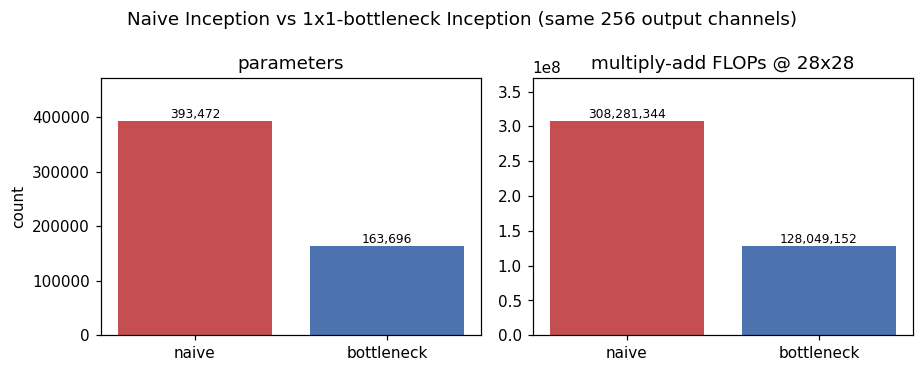

FLOP reduction: 2.41x fewer multiply-adds


In [6]:
# Compare params AND multiply-add FLOPs (naive vs bottleneck) with a bar chart.
def conv_flops(conv, H, W):
    # multiply-adds for a Conv2d producing an HxW output (stride 1, same padding)
    kh, kw = conv.kernel_size
    return conv.in_channels * conv.out_channels * kh * kw * H * W

def module_flops(m, H, W):
    return sum(conv_flops(c, H, W) for c in m.modules() if isinstance(c, nn.Conv2d))

H = W = 28
naive_p, bott_p = count_params(naive), count_params(bott)
naive_f, bott_f = module_flops(naive, H, W), module_flops(bott, H, W)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4))
axes[0].bar(['naive', 'bottleneck'], [naive_p, bott_p], color=['#C44E52', '#4C72B0'])
axes[0].set_title('parameters'); axes[0].set_ylabel('count')
axes[1].bar(['naive', 'bottleneck'], [naive_f, bott_f], color=['#C44E52', '#4C72B0'])
axes[1].set_title(f'multiply-add FLOPs @ {H}x{W}')
for ax, a, b in [(axes[0], naive_p, bott_p), (axes[1], naive_f, bott_f)]:
    for i, v in enumerate([a, b]):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
    ax.margins(y=0.2)
plt.suptitle('Naive Inception vs 1x1-bottleneck Inception (same 256 output channels)')
plt.tight_layout(); plt.show()
print(f'FLOP reduction: {naive_f/bott_f:.2f}x fewer multiply-adds')

### Widget 2: how far do the 1x1 reductions cut cost?

**Try this.** Move the reduction-channel sliders down. The bottleneck bar shrinks well below the naive bar, yet the module still outputs the same 256 channels. Very small reductions save the most, at some cost to representational capacity.

In [7]:
def inception_compare(c3red=96, c5red=16):
    b = InceptionBottleneck(192, c1=64, c3red=c3red, c3=128, c5red=c5red, c5=32, cpool=32)
    naive_p = count_params(naive)
    bott_p  = count_params(b)
    fig, ax = plt.subplots(figsize=(6.2, 3.4))
    bars = ax.bar(['naive\n(no reduction)', f'bottleneck\n(3x3red={c3red}, 5x5red={c5red})'],
                  [naive_p, bott_p], color=['#C44E52', '#4C72B0'])
    ax.set_ylabel('parameters')
    ax.set_title(f'Inception params: {naive_p/bott_p:.2f}x fewer with bottleneck')
    for bar, v in zip(bars, [naive_p, bott_p]):
        ax.text(bar.get_x()+bar.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
    ax.margins(y=0.2)
    plt.tight_layout(); plt.show()

interact(inception_compare,
         c3red=widgets.IntSlider(min=8, max=192, step=8, value=96, description='3x3 reduce'),
         c5red=widgets.IntSlider(min=8, max=96,  step=8, value=16, description='5x5 reduce'));

interactive(children=(IntSlider(value=96, description='3x3 reduce', max=192, min=8, step=8), IntSlider(value=1…

## 3. A mini GoogLeNet (InceptionNet)

**Why it matters.** GoogLeNet showed that a carefully designed architecture can be both **accurate and small**. It won ILSVRC 2014 with about **5M parameters**, roughly **12x fewer than AlexNet's ~60M**, thanks to the 1x1 bottlenecks and by replacing giant fully connected layers with global average pooling.

**Anatomy.**
* **Stem:** a few plain conv and pooling layers (Conv, Pool, 2x Conv, Pool) that quickly reduce spatial size.
* **Body:** several **stacked Inception modules**, with occasional max-pool to downsample.
* **Head:** **global average pooling** collapses each channel to a single number, followed by a **single linear classifier** (no huge FC stack).
* **Auxiliary classifiers:** the real GoogLeNet attaches small extra classifiers at intermediate depths during training. They **inject gradient** partway through the network, helping the deep stack train (an early answer to vanishing gradients, later made cleaner by ResNet).

In [8]:
class MiniGoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Stem: Conv - Pool - 2x Conv - Pool
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
            nn.Conv2d(64, 64, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        # Body: two inception modules + a downsampling pool
        self.inc1 = InceptionBottleneck(192, 64, 96, 128, 16, 32, 32)   # -> 256 ch
        self.inc2 = InceptionBottleneck(256, 128, 128, 192, 32, 96, 64) # -> 480 ch
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)
        # Head: global average pool + single linear classifier
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(480, num_classes)

    def forward(self, x, trace=False):
        def log(name, t):
            if trace: print(f'{name:<12}: {tuple(t.shape)}')
        log('input', x)
        x = self.stem(x); log('after stem', x)
        x = self.inc1(x); log('after inc1', x)
        x = self.inc2(x); log('after inc2', x)
        x = self.pool(x); log('after pool', x)
        x = self.gap(x);  log('after gap', x)
        x = torch.flatten(x, 1)
        x = self.fc(x);   log('logits', x)
        return x

net = MiniGoogLeNet(num_classes=10)
img = torch.randn(1, 3, 64, 64)  # a tiny 3x64x64 image
logits = net(img, trace=True)
print(f'\nMiniGoogLeNet total parameters: {count_params(net):,}')

input       : (1, 3, 64, 64)
after stem  : (1, 192, 8, 8)
after inc1  : (1, 256, 8, 8)
after inc2  : (1, 480, 8, 8)
after pool  : (1, 480, 4, 4)
after gap   : (1, 480, 1, 1)
logits      : (1, 10)

MiniGoogLeNet total parameters: 681,658


## 4. The degradation problem

**Why it matters.** Once bottlenecks made depth affordable, a puzzle appeared: **more layers made things worse**, and not because of overfitting.

**The observation (He et al., 2015).**
* A plain **56-layer** network has **higher training error** than a plain **20-layer** network, and also higher test error.
* Higher **training** error rules out overfitting: this is **underfitting / an optimization failure**, not a generalization gap.

**Why it is counterintuitive.** The deeper network is a **superset** of the shallower one: it could copy the 20-layer network and set the extra layers to the **identity** and match it exactly. In practice, plain stacked layers struggle to learn identity mappings, so optimization gets harder as depth grows. This motivates residual learning.

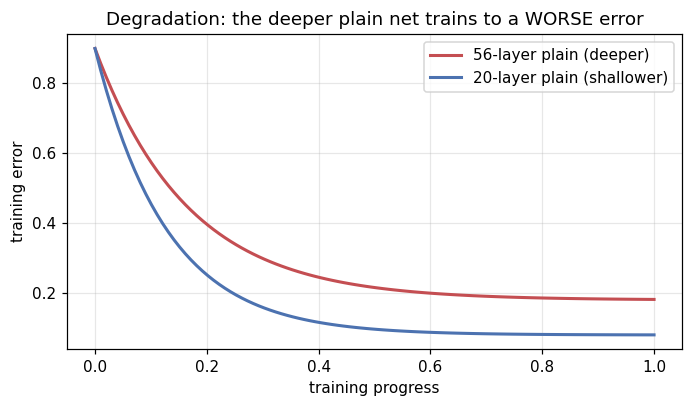

Key point: this is on TRAINING error, so it is underfitting, not overfitting.


In [9]:
# Schematic of the degradation effect (illustrative curves, not measured data).
iters = np.linspace(0, 1, 100)
def curve(floor, speed):
    return floor + (0.9 - floor) * np.exp(-speed * iters * 6)

err20 = curve(floor=0.08, speed=1.3)   # 20-layer plain net
err56 = curve(floor=0.18, speed=1.0)   # 56-layer plain net settles HIGHER

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(iters, err56, color='#C44E52', lw=2, label='56-layer plain (deeper)')
ax.plot(iters, err20, color='#4C72B0', lw=2, label='20-layer plain (shallower)')
ax.set_xlabel('training progress'); ax.set_ylabel('training error')
ax.set_title('Degradation: the deeper plain net trains to a WORSE error')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Key point: this is on TRAINING error, so it is underfitting, not overfitting.')

## 5. Vanishing and exploding gradients

**Why it matters.** The degradation problem is closely tied to how gradients travel back through many layers.

**The mechanism.** Backprop through $L$ layers multiplies $L$ Jacobians together:
$$\frac{\partial \mathcal{L}}{\partial x_0} = \frac{\partial \mathcal{L}}{\partial x_L}\prod_{i=1}^{L}\frac{\partial x_i}{\partial x_{i-1}}.$$
* Each factor typically involves the **activation derivative**. For the **sigmoid**, that derivative is at most $\tfrac14$ (it peaks at 0.25 and is tiny in the saturated tails).
* Multiplying many sub-1 numbers makes the product **shrink exponentially with depth**: early layers get almost **no gradient** (vanishing). If factors are consistently above 1, the product **explodes** instead.

Let us watch a deep plain stack lose its gradient signal.

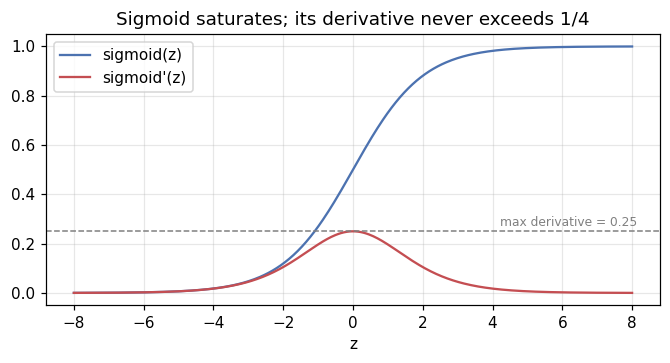

In [10]:
# Plot the sigmoid and its derivative (peak 0.25).
z = torch.linspace(-8, 8, 400)
s = torch.sigmoid(z)
ds = s * (1 - s)
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(z, s, label='sigmoid(z)', color='#4C72B0')
ax.plot(z, ds, label="sigmoid'(z)", color='#C44E52')
ax.axhline(0.25, ls='--', color='gray', lw=1)
ax.text(4.2, 0.27, 'max derivative = 0.25', color='gray', fontsize=8)
ax.set_xlabel('z'); ax.set_title('Sigmoid saturates; its derivative never exceeds 1/4')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

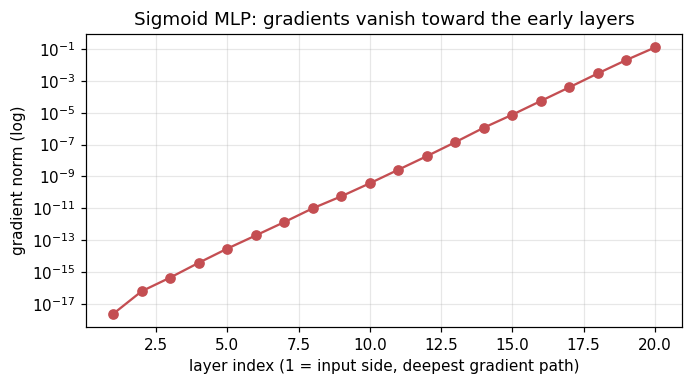

gradient norm at last layer / first layer: 1.2e+11


In [11]:
class DeepMLP(nn.Module):
    """A deep stack of Linear + activation, for probing gradient flow."""
    def __init__(self, depth=20, width=64, act='sigmoid'):
        super().__init__()
        acts = {'sigmoid': nn.Sigmoid, 'tanh': nn.Tanh, 'relu': nn.ReLU}
        self.layers = nn.ModuleList()
        for _ in range(depth):
            self.layers.append(nn.Linear(width, width))
            self.layers.append(acts[act]())

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

def layer_grad_norms(model, width=64, batch=64):
    """One backward pass on random data; return grad norm of each Linear layer."""
    model.zero_grad()
    x = torch.randn(batch, width)
    out = model(x)
    loss = out.pow(2).mean()   # arbitrary scalar objective
    loss.backward()
    return [l.weight.grad.norm().item()
            for l in model.layers if isinstance(l, nn.Linear)]

torch.manual_seed(0)
model = DeepMLP(depth=20, width=64, act='sigmoid')
norms = layer_grad_norms(model)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(range(1, len(norms)+1), norms, marker='o', color='#C44E52')
ax.set_yscale('log')
ax.set_xlabel('layer index (1 = input side, deepest gradient path)')
ax.set_ylabel('gradient norm (log)')
ax.set_title('Sigmoid MLP: gradients vanish toward the early layers')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'gradient norm at last layer / first layer: {norms[-1]/max(norms[0],1e-12):.1e}')

### Widget 3: gradient flow vs depth and activation

**Try this.** Switch the activation to **sigmoid** and increase depth: the early-layer gradients collapse toward zero (a nearly vertical drop on the log axis). Switch to **relu**: the curve stays far flatter because the ReLU derivative is 1 wherever the unit is active, so it does not shrink the product.

In [12]:
def grad_flow(depth=20, activation='sigmoid'):
    torch.manual_seed(0)
    m = DeepMLP(depth=depth, width=64, act=activation)
    norms = layer_grad_norms(m)
    fig, ax = plt.subplots(figsize=(6.6, 3.6))
    ax.plot(range(1, len(norms)+1), norms, marker='o',
            color={'sigmoid':'#C44E52','tanh':'#DD8452','relu':'#4C72B0'}[activation])
    ax.set_yscale('log')
    ax.set_xlabel('layer index (input side -> output side)')
    ax.set_ylabel('gradient norm (log)')
    ax.set_title(f'{activation}, depth={depth}: '
                 f'first/last grad ratio = {norms[0]/max(norms[-1],1e-12):.1e}')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(grad_flow,
         depth=widgets.IntSlider(min=4, max=50, step=2, value=20, description='depth'),
         activation=widgets.Dropdown(options=['sigmoid','tanh','relu'],
                                     value='sigmoid', description='activation'));

interactive(children=(IntSlider(value=20, description='depth', max=50, min=4, step=2), Dropdown(description='a…

## 6. Residual learning (ResNet)

**Why it matters.** ResNet solved both the degradation problem and vanishing gradients with one tiny structural change, and enabled networks over 100 layers deep.

**The idea.** Instead of asking a block to learn the full target mapping $H(x)$ directly, ask it to learn the **residual** $F(x) = H(x) - x$ and then add the input back:
$$y = F(x) + x.$$
* The $+x$ term is an **identity skip connection** (a shortcut that copies the input forward).
* Learning an **identity mapping is now trivial**: just drive the weights of $F$ toward 0, and the block outputs $x$ unchanged. Extra layers can no longer hurt.
* In backprop, the skip gives the gradient a **highway**: $\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + I$. The $+I$ term passes gradient straight through, so it does not vanish even through many blocks.

**Shortcut with a projection.** When the block changes the channel count or spatial size (stride 2), the shortcut cannot be a bare copy, so we use a **1x1 conv** on the skip path to match shapes.

In [13]:
class BasicResidualBlock(nn.Module):
    """Two 3x3 conv + BN, ReLU, with an identity (or 1x1-projected) skip."""
    def __init__(self, C_in, C_out, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(C_in, C_out, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(C_out)
        self.conv2 = nn.Conv2d(C_out, C_out, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(C_out)
        # Shortcut: identity when shapes match, else a 1x1 conv projection.
        if stride != 1 or C_in != C_out:
            self.shortcut = nn.Sequential(
                nn.Conv2d(C_in, C_out, 1, stride=stride, bias=False),
                nn.BatchNorm2d(C_out))
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)   # the residual add
        return F.relu(out)

# Same-shape block: skip is a bare identity.
blk = BasicResidualBlock(64, 64)
x = torch.randn(1, 64, 32, 32)
print('same-shape block :', tuple(x.shape), '->', tuple(blk(x).shape),
      '| shortcut =', type(blk.shortcut).__name__)

# Downsampling block: channels double and spatial halves, skip uses a 1x1 conv.
blk2 = BasicResidualBlock(64, 128, stride=2)
print('downsample block :', tuple(x.shape), '->', tuple(blk2(x).shape),
      '| shortcut =', type(blk2.shortcut).__name__)

same-shape block : (1, 64, 32, 32) -> (1, 64, 32, 32) | shortcut = Identity
downsample block : (1, 64, 32, 32) -> (1, 128, 16, 16) | shortcut = Sequential


### The key experiment: does the skip connection really help gradients?

We build a **deep plain net** (residual add removed) and a **deep residual net** with identical layers, run **one backward pass** on each, and compare the per-layer gradient norms. The residual net should keep early-layer gradients healthy while the plain net's gradients decay.

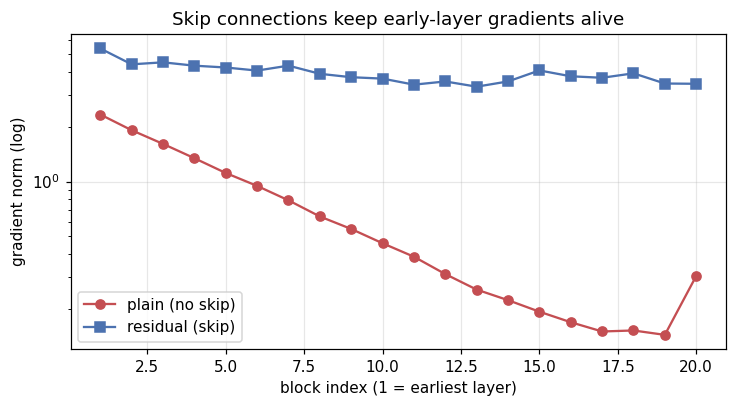

plain    early/late grad ratio: 7.7e+00
residual early/late grad ratio: 1.6e+00


In [14]:
class ConvUnit(nn.Module):
    """One 3x3 conv + BN + ReLU, optionally with a residual skip."""
    def __init__(self, C, use_skip):
        super().__init__()
        self.conv = nn.Conv2d(C, C, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(C)
        self.use_skip = use_skip
    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        return out + x if self.use_skip else out

class DeepConvNet(nn.Module):
    def __init__(self, n_blocks=20, C=32, use_skip=False):
        super().__init__()
        self.stem = nn.Conv2d(3, C, 3, padding=1, bias=False)
        self.blocks = nn.ModuleList([ConvUnit(C, use_skip) for _ in range(n_blocks)])
    def forward(self, x):
        x = self.stem(x)
        for b in self.blocks:
            x = b(x)
        return x

def block_grad_norms(model, batch=8):
    model.zero_grad()
    x = torch.randn(batch, 3, 16, 16)
    model(x).pow(2).mean().backward()
    return [b.conv.weight.grad.norm().item() for b in model.blocks]

torch.manual_seed(0); plain = DeepConvNet(20, use_skip=False)
torch.manual_seed(0); resid = DeepConvNet(20, use_skip=True)
gp, gr = block_grad_norms(plain), block_grad_norms(resid)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(range(1, len(gp)+1), gp, marker='o', color='#C44E52', label='plain (no skip)')
ax.plot(range(1, len(gr)+1), gr, marker='s', color='#4C72B0', label='residual (skip)')
ax.set_yscale('log')
ax.set_xlabel('block index (1 = earliest layer)')
ax.set_ylabel('gradient norm (log)')
ax.set_title('Skip connections keep early-layer gradients alive')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'plain    early/late grad ratio: {gp[0]/max(gp[-1],1e-12):.1e}')
print(f'residual early/late grad ratio: {gr[0]/max(gr[-1],1e-12):.1e}')

### Widget 4: skip connection on/off

**Try this.** With the skip **on**, the gradient-norm curve stays roughly **flat** across all blocks (the identity highway). Turn it **off** and increase the number of blocks: the early-block gradients slide toward zero, the vanishing-gradient signature that made deep plain nets so hard to train.

In [15]:
def skip_demo(n_blocks=20, skip_on=True):
    torch.manual_seed(0)
    m = DeepConvNet(n_blocks=n_blocks, use_skip=skip_on)
    g = block_grad_norms(m)
    fig, ax = plt.subplots(figsize=(6.8, 3.8))
    ax.plot(range(1, len(g)+1), g, marker='o',
            color=('#4C72B0' if skip_on else '#C44E52'),
            label=('skip ON' if skip_on else 'skip OFF'))
    ax.set_yscale('log')
    ax.set_xlabel('block index (1 = earliest layer)')
    ax.set_ylabel('gradient norm (log)')
    ax.set_title(f"skip={'ON' if skip_on else 'OFF'}, blocks={n_blocks}: "
                 f"early/late ratio = {g[0]/max(g[-1],1e-12):.1e}")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(skip_demo,
         n_blocks=widgets.IntSlider(min=4, max=40, step=2, value=20, description='blocks'),
         skip_on=widgets.Checkbox(value=True, description='skip connection'));

interactive(children=(IntSlider(value=20, description='blocks', max=40, min=4, step=2), Checkbox(value=True, d…

## 7. The bottleneck residual block

**Why it matters.** For very deep ResNets (50, 101, 152 layers) even 3x3 convs on wide channels get expensive. The **bottleneck block** borrows the GoogLeNet trick: shrink, process, expand.

**Structure (three convs).**
* **1x1 reduce:** drop the channel depth (e.g. 256 -> 64).
* **3x3:** do the spatial processing on the cheap, reduced depth.
* **1x1 expand:** restore the depth back up (64 -> 256) so the residual add lines up.

Same residual idea as the basic block, but far fewer multiply-adds for the same input/output width.

In [16]:
class BottleneckBlock(nn.Module):
    """1x1 reduce -> 3x3 -> 1x1 expand, with a residual skip. ResNet-50 style."""
    expansion = 4
    def __init__(self, C_in, C_mid, stride=1):
        super().__init__()
        C_out = C_mid * self.expansion
        self.conv1 = nn.Conv2d(C_in, C_mid, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(C_mid)
        self.conv2 = nn.Conv2d(C_mid, C_mid, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(C_mid)
        self.conv3 = nn.Conv2d(C_mid, C_out, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(C_out)
        if stride != 1 or C_in != C_out:
            self.shortcut = nn.Sequential(nn.Conv2d(C_in, C_out, 1, stride=stride, bias=False),
                                          nn.BatchNorm2d(C_out))
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = out + self.shortcut(x)
        return F.relu(out)

x = torch.randn(1, 256, 14, 14)
bott_blk = BottleneckBlock(256, 64)         # 256 -> (64) -> 256
print('bottleneck block:', tuple(x.shape), '->', tuple(bott_blk(x).shape))

# Compare a basic vs bottleneck block for the SAME 256-in / 256-out.
basic_256 = BasicResidualBlock(256, 256)
print(f'\nBasic block  (256->256) params: {count_params(basic_256):,}')
print(f'Bottleneck   (256->256) params: {count_params(bott_blk):,}')
print(f'Bottleneck is {count_params(basic_256)/count_params(bott_blk):.2f}x cheaper in params')

bottleneck block: (1, 256, 14, 14) -> (1, 256, 14, 14)

Basic block  (256->256) params: 1,180,672
Bottleneck   (256->256) params: 70,400
Bottleneck is 16.77x cheaper in params


**Putting it together (the real ResNet).** A full ResNet is a stem, four stages of stacked residual blocks (basic blocks for ResNet-18/34, bottleneck blocks for ResNet-50/101/152), then **global average pooling** and a **single fully connected** classifier. The depth suffix (34, 50, 101, 152) just counts the layers. The design is remarkably uniform: the same block repeated, with the skip connection doing the heavy lifting.

## Key takeaways

* The **1x1 convolution** mixes channels while preserving space, and is the cheapest way to reduce depth: params $= C_{in} C_{out}$, FLOPs $= C_{in} C_{out} H W$.
* The **Inception module** runs multiple receptive fields in parallel and concatenates them; **1x1 bottlenecks** before the 3x3/5x5 convs cut params and FLOPs dramatically.
* **GoogLeNet** used these ideas plus global average pooling to reach ~5M params, about 12x smaller than AlexNet, while being more accurate.
* Naively stacking plain layers causes the **degradation problem**: worse **training** error, an optimization failure (not overfitting), rooted in **vanishing gradients** (sigmoid derivative $\le 0.25$).
* **Residual blocks** learn $F(x)=H(x)-x$ and output $F(x)+x$; the identity skip makes identity mappings trivial and gives gradients a **highway**, keeping early layers trainable.
* **Bottleneck residual blocks** (1x1 reduce, 3x3, 1x1 expand) make very deep ResNets (50/101/152) affordable.

## Further reading

* Szegedy et al., **"Going Deeper with Convolutions"** (GoogLeNet / Inception), CVPR 2015.
* He, Zhang, Ren, Sun, **"Deep Residual Learning for Image Recognition"** (ResNet), CVPR 2016.
* R. Raghav, **"Illustrated: 10 CNN Architectures"**, Towards Data Science tutorial (a visual tour of AlexNet through ResNet and beyond).